# VisionVoice EDA and Data Preparation

This shared notebook prepares the official VizWiz-Captions validation set for image-captioning experiments. It audits annotation quality, removes unusable captions, creates leakage-free internal train/validation/test splits, and checks vocabulary coverage before model training.


# 1. Project Context


## 1.1 Task Motivation

Image captioning combines computer vision and natural language processing: the model must understand an image and generate a short natural-language description. For VisionVoice, the goal is especially relevant to accessibility because VizWiz images are taken by people who are blind or have low vision.

The modelling notebooks use an encoder-decoder design. A pretrained CNN encoder extracts visual features, and a sequence decoder such as an LSTM generates captions token by token. This EDA notebook prepares the data that both model architectures rely on.


## 1.2 Evaluation Approach

The assignment requires BLEU-1, BLEU-2, BLEU-3, and BLEU-4. These metrics compare generated captions against human reference captions using unigram through 4-gram overlap.

BLEU is useful for consistent comparison, but it cannot fully judge whether a caption is visually grounded. For that reason, the modelling notebook also includes qualitative visual inspection after training.


## 1.3 Dataset Scope

This project uses only the official VizWiz-Captions validation set, as required by the assignment. The raw split contains **7,750 images** and **38,750 captions**, with five human-written captions per image before cleaning.

VizWiz is more difficult than curated captioning datasets because images often contain blur, poor lighting, partial objects, unusual framing, and accessibility-specific quality issues. These characteristics make data cleaning and careful evaluation important.


## 1.4 Assignment Workflow

This notebook supports **Phase 1: Shared Data Preparation**. It covers loading the dataset, cleaning and tokenising captions, building the vocabulary, creating internal train/validation/test splits, and preparing the data structures used by PyTorch.

The modelling notebook then covers **Phase 2: Model 1** and **Phase 3: Model 2**, including the baseline architecture, the refined attention architecture, and evaluation for both models.


# 2. Environment and Configuration


## 2.1 Runtime Check


In [1]:
import os
import platform
import sys

print(f'Python : {sys.version}')
print(f'OS     : {platform.system()} {platform.release()}')
print(f'CWD    : {os.getcwd()}')

Python : 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
OS     : Linux 6.6.122+
CWD    : /kaggle/working


## 2.2 Libraries

The notebook uses PyTorch for tensor operations and future data-loader compatibility, Pandas and NumPy for structured analysis, Matplotlib for lightweight GitHub-friendly plots, and standard Python utilities for reproducibility and filesystem handling.


In [2]:
# Standard Python Utilities
import os, sys, gc, time, json, random, zipfile, warnings, shutil
from pathlib import Path
from typing import List, Dict, Tuple, Optional, Iterable, Any
from collections import Counter

# Networking
import requests

# Data Processing
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Image Processing
from PIL import Image, UnidentifiedImageError

# Visualization
import matplotlib.pyplot as plt

# Deep Learning (PyTorch)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import torchvision.models as models
import torchvision.transforms as transforms

# NLP & Progress
import nltk
from nltk.translate.bleu_score import corpus_bleu
from tqdm import tqdm

# Suppress non-critical warnings for cleaner output
warnings.filterwarnings('ignore')

# Centralized Device Configuration
# This ensures we have a single source of truth for hardware acceleration
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print(f"Python       : {sys.version.split()[0]}")
print(f"PyTorch      : {torch.__version__}")
print(f"Target Device: {DEVICE}")

Python       : 3.12.12
PyTorch      : 2.10.0+cpu
Target Device: cpu


## 2.3 Configuration

The `Settings` class centralizes paths, random seed values, data-split parameters, vocabulary settings, and display switches. Keeping these values in one place makes the notebook easier to rerun on Kaggle and easier for the modelling notebook to mirror.


In [3]:
class Settings:
    """Centralized configuration class for the Image Captioning project.

    Contains all hyperparameters, environment settings, and dynamic path
    routing for both Kaggle and local VS Code environments.
    """

    # 1. Operational Toggles
    MODE: str = "eda"   # "eda", "train", or "inference"
    DEBUG: bool = False
    DEBUG_SAMPLE_SIZE: int = 50 # Number of files to audit when DEBUG is True
    SHOW_EDA_PLOTS: bool = MODE == "eda"  # Dataset/EDA figures
    SHOW_MODEL_PLOTS: bool = MODE in {"train", "inference"}  # Post-training diagnostics

    # 2. Environment Detection
    IS_KAGGLE: bool = Path("/kaggle/input").exists()

    # 3. Dynamic Path Management
    # Override these in Kaggle with environment variables if your dataset slug changes:
    # VIZWIZ_DATA_DIR, VIZWIZ_ANNOTATIONS_DIR, VIZWIZ_IMAGE_DIR
    if IS_KAGGLE:
        DATA_DIR = Path(os.getenv("VIZWIZ_DATA_DIR", "/kaggle/input/datasets/tuannm3823/vizwiz"))
        ANNOTATIONS_DIR = Path(os.getenv("VIZWIZ_ANNOTATIONS_DIR", str(DATA_DIR / "annotations" / "annotations")))
        TRAIN_IMG_DIR = Path(os.getenv("VIZWIZ_IMAGE_DIR", str(DATA_DIR / "val" / "val")))
        VAL_IMG_DIR = TRAIN_IMG_DIR
        WORK_DIR = Path("/kaggle/working")
    else:
        try:
            from google.colab import drive
            drive.mount('/content/drive')
            DATA_DIR = Path(os.getenv("VIZWIZ_LOCAL_DATA_DIR", "/content/drive/MyDrive/Sem3_2026 Autumn/94691 Deep Learning/dl_assignments/dl_at3"))
        except ImportError:
            DATA_DIR = Path(os.getenv("VIZWIZ_LOCAL_DATA_DIR", "./data"))

        ANNOTATIONS_DIR = DATA_DIR / "annotations"
        TRAIN_IMG_DIR = DATA_DIR / "images"
        VAL_IMG_DIR = DATA_DIR / "images"
        WORK_DIR = DATA_DIR / "working"

    BASE: Path = DATA_DIR
    CACHE_DIR: Path = WORK_DIR / "cache"
    WORK_CACHE_DIR: Path = CACHE_DIR / "work"

    # /kaggle/input/models/tuannm3823/visionvoice-image-captioning/pytorch/attention-resnet-lstm/1/vision_voice_attention_best.pth
    # /kaggle/input/models/tuannm3823/visionvoice-image-captioning/pytorch/baseline-resnet-lstm/1/vision_voice_baseline_best.pth

    # 4. Remote Data URLs (For Section 3.1)
    URL_ANNOTATIONS: str = "https://vizwiz.cs.colorado.edu/VizWiz_final/annotations/val.json"
    URL_IMAGES: str = "https://vizwiz.cs.colorado.edu/VizWiz_final/images/val.zip"

    # 5. Data Processing & Pipeline Parameters
    SEED: int = 42
    VAL_SPLIT_SIZE: float = 0.1    # 10% internal validation split for model selection
    TEST_SPLIT_SIZE: float = 0.1   # 10% internal test split for final reporting
    VOCAB_MIN_FREQ: int = 2        # Minimum word occurrences to be indexed
    IMAGE_SIZE: int = 224          # ResNet standard input size
    NUM_WORKERS: int = 2           # DataLoader subprocesses

    # 6. Model Hyperparameters
    LEARNING_RATE: float = 1e-4
    BATCH_SIZE: int = 32
    EPOCHS: int = 10
    MAX_SEQ_LEN: int = 25          # Max words generated during inference
    EMBED_SIZE: int = 256          # Dimension of shared visual/textual space
    HIDDEN_SIZE: int = 512         # Number of units in LSTM hidden state
    NUM_LAYERS: int = 1            # Number of LSTM layers stacked
    MAX_GRAD_NORM: float = 5.0     # Clipping threshold for vanishing/exploding gradients

    # 7. Evaluation Parameters
    BLEU_EVAL_SAMPLES: int = 500   # Number of validation images to test for BLEU scoring

# Instantiate configuration object
CFG = Settings()

# Post-instantiation directory setup
CFG.CACHE_EXISTS = CFG.CACHE_DIR.exists()
CFG.WORK_CACHE_DIR.mkdir(parents=True, exist_ok=True)

print(f'MODE         : {CFG.MODE}')
print(f'BASE         : {CFG.BASE}')
print(f'CACHE_EXISTS : {CFG.CACHE_EXISTS}')
print(f'CACHE_DIR    : {CFG.CACHE_DIR}')

MODE         : eda
BASE         : /kaggle/input/datasets/tuannm3823/vizwiz
CACHE_EXISTS : False
CACHE_DIR    : /kaggle/working/cache


## 2.4 Memory Utilities

VizWiz is large enough that memory use matters on Kaggle. The helper functions release unused memory and downcast numeric DataFrame columns where possible, keeping analysis stable without changing the meaning of the data.


In [4]:
def clear_memory() -> None:
    """Forces garbage collection and clears VRAM cache to prevent OOM errors."""
    gc.collect()

    # Clear CUDA cache if using NVIDIA
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    # Clear MPS cache if using Apple Silicon
    elif torch.backends.mps.is_available():
        torch.mps.empty_cache()

    if CFG.DEBUG:
        print("[Memory] Garbage collection forced and accelerator cache cleared.")


def reduce_mem_usage(df: pd.DataFrame) -> pd.DataFrame:
    """
    Iterates through all columns of a dataframe and downcasts data types
    to their smallest possible representation to reduce memory footprint.
    """
    start_mem = df.memory_usage().sum() / 1024**2

    for col in df.columns:
        col_type = df[col].dtype

        # Exclude object (string) and categorical types from numeric downcasting
        if col_type != object and not pd.api.types.is_categorical_dtype(col_type):
            c_min = df[col].min()
            c_max = df[col].max()

            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                else:
                    df[col] = df[col].astype(np.int64)
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)

    end_mem = df.memory_usage().sum() / 1024**2

    if CFG.DEBUG:
        reduction = 100 * (start_mem - end_mem) / start_mem
        print(f"[Memory] DataFrame compressed from {start_mem:.2f}MB to {end_mem:.2f}MB ({reduction:.1f}% reduction).")

    return df

## 2.5 Reproducibility

The notebook fixes random seeds across Python, NumPy, and PyTorch. This keeps the internal image-level splits stable across reruns and ensures each team member works from the same prepared data.


In [5]:
def seed_everything(seed: int = CFG.SEED) -> None:
    """
    Locks all random number generators to a specific seed to ensure
    Global Determinism across independent experimental runs.
    """
    # 1. Python and Data structures
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

    # 2. NumPy
    np.random.seed(seed)

    # 3. PyTorch Core
    torch.manual_seed(seed)

    # 4. PyTorch CUDA (Hardware Acceleration)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed) # Ensures determinism for multi-GPU setups

        # Enforce deterministic convolutions.
        # Note: This may slightly reduce training speed, but guarantees 100% reproducible results.
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

    print(f"Global seed successfully locked to: {seed}")

# Execute initialization
seed_everything(CFG.SEED)

Global seed successfully locked to: 42


# 3. Dataset Loading


## 3.1 Data Access

This section locates the VizWiz image folder and annotation JSON, using Kaggle paths when available and local paths otherwise. The goal is to make the same notebook runnable in both environments without manual path edits.


In [6]:
def download_file(url: str, dest_dir: Path, filename: str = None) -> Path:
    """
    Downloads a file from a URL using chunked streaming to prevent OOM errors.

    Args:
        url (str): The source URL.
        dest_dir (Path): The local directory to save the file.
        filename (str, optional): Custom filename. Defaults to URL's trailing name.

    Returns:
        Path: The absolute path to the downloaded file.
    """
    dest_dir.mkdir(parents=True, exist_ok=True)
    filename = filename or url.split("/")[-1]
    file_path = dest_dir / filename

    if file_path.exists():
        print(f"[Network] '{filename}' already exists in cache. Skipping download.")
        return file_path

    print(f"[Network] Initiating stream for '{filename}'...")
    try:
        # Stream=True prevents loading the entire file into RAM at once
        with requests.get(url, stream=True, timeout=15) as response:
            response.raise_for_status()
            with open(file_path, "wb") as file:
                for chunk in response.iter_content(chunk_size=8192):
                    if chunk:
                        file.write(chunk)
        print(f"[Network] Successfully downloaded: {file_path}")
    except requests.exceptions.RequestException as e:
        print(f"[Error] Failed to download {filename}: {e}")
        raise SystemExit("Critical data missing. Pipeline halted.")

    return file_path

def prepare_dataset() -> None:
    """
    Orchestrates the data pipeline: routing Kaggle paths or downloading/extracting
    the VizWiz dataset into the local Colab environment.
    """
    if CFG.IS_KAGGLE:
        print("[Pipeline] Kaggle environment detected. Utilizing read-only mounted datasets.")
        if not (CFG.ANNOTATIONS_DIR / "val.json").exists():
             print(f"[Warning] val.json not found in {CFG.ANNOTATIONS_DIR}.")
        return

    print("--- Initializing Local Data Pipeline ---")

    # 1. Acquire Annotations (Metadata)
    CFG.ANNOTATIONS_DIR.mkdir(parents=True, exist_ok=True)
    download_file(
        url=CFG.URL_ANNOTATIONS,
        dest_dir=CFG.ANNOTATIONS_DIR,
        filename="val.json"
    )

    # 2. Acquire and Extract Images
    # We verify extraction success by checking if the directory exists and is populated
    if CFG.TRAIN_IMG_DIR.exists() and any(CFG.TRAIN_IMG_DIR.iterdir()):
        print(f"[Pipeline] Image payload verified at: {CFG.TRAIN_IMG_DIR}. Skipping extraction.")
    else:
        print(f"[Pipeline] Image directory empty. Beginning extraction protocol...")
        CFG.TRAIN_IMG_DIR.mkdir(parents=True, exist_ok=True)

        # Download the heavy zip file to the temporary cache
        zip_path = download_file(CFG.URL_IMAGES, CFG.WORK_CACHE_DIR)

        print(f"[Storage] Unpacking compressed images to {CFG.TRAIN_IMG_DIR}...")
        try:
            with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                # Extract to a temp cache folder to handle unexpected internal nested folders
                temp_extract_path = CFG.WORK_CACHE_DIR / "temp_extract"
                temp_extract_path.mkdir(exist_ok=True)
                zip_ref.extractall(temp_extract_path)

                # Flatten the directory structure if the zip contained a root 'val' folder
                extracted_items = list(temp_extract_path.iterdir())
                if len(extracted_items) == 1 and extracted_items[0].is_dir():
                    source_dir = extracted_items[0]
                else:
                    source_dir = temp_extract_path

                # Move files to final persistent directory
                for item in source_dir.iterdir():
                    shutil.move(str(item), str(CFG.TRAIN_IMG_DIR / item.name))

                # Housekeeping: Clean up temporary extraction folders
                shutil.rmtree(temp_extract_path)

            print("[Storage] Extraction and cleanup complete.")

        except zipfile.BadZipFile:
            print(f"[Error] Corrupted archive detected at {zip_path}.")
            zip_path.unlink() # Delete corrupted zip to force fresh download on next run
            raise SystemExit("Please re-run the cell to attempt download again.")

# Execute Pipeline
prepare_dataset()

[Pipeline] Kaggle environment detected. Utilizing read-only mounted datasets.


## 3.2 Annotation Parsing

VizWiz annotations are stored in JSON with image metadata and captions linked by image identifiers. This section converts the raw JSON into tabular DataFrames and joins captions to file names for analysis, cleaning, and later model input.


In [7]:
print(f"--- Parsing Raw Annotations ---")
json_path = CFG.ANNOTATIONS_DIR / "val.json"

# 1. Load the Raw Data
with open(json_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

images_df = pd.DataFrame(data['images'])
annotations_df = pd.DataFrame(data['annotations'])

# 2. Basic Text Cleanup (Fix legacy carriage returns that break tokenizers)
annotations_df['caption'] = annotations_df['caption'].str.replace('\r', '', regex=False)

# 3. Initial Merge (Attach file_names to captions for Visualization & EDA)
raw_corpus_df = pd.merge(
    annotations_df,
    images_df[['id', 'file_name']],
    left_on='image_id',
    right_on='id',
    how='inner'
)
# Rename the annotation's 'id' column to avoid confusion, drop the duplicate image 'id'
raw_corpus_df = raw_corpus_df.drop(columns=['id_y']).rename(columns={'id_x': 'annotation_id'})

print(f"Successfully loaded {len(raw_corpus_df)} raw annotations.\n")

--- Parsing Raw Annotations ---
Successfully loaded 38750 raw annotations.



## 3.3 Raw Sample Inspection

Before filtering, the notebook displays raw image-caption examples and keeps flagged captions visible. This helps confirm that rejected or precanned annotations are genuine label-quality issues rather than useful captions.


--- [Visualization] Sampling 3 raw images ---


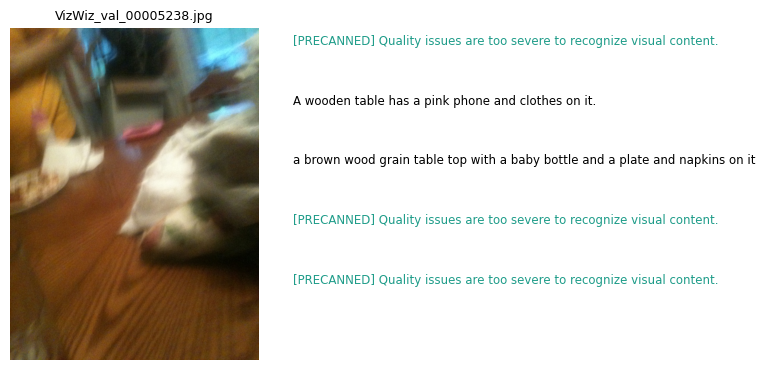

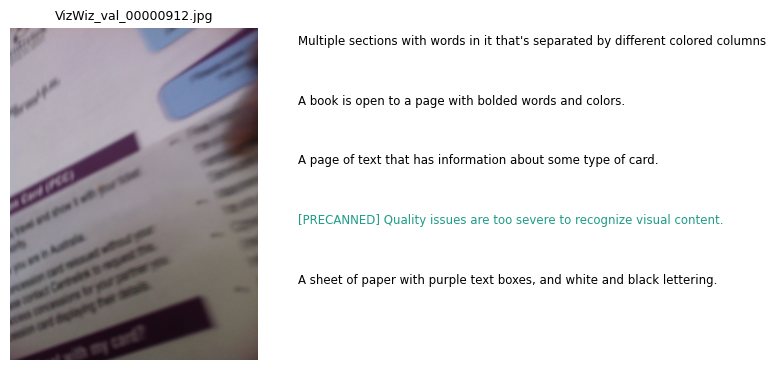

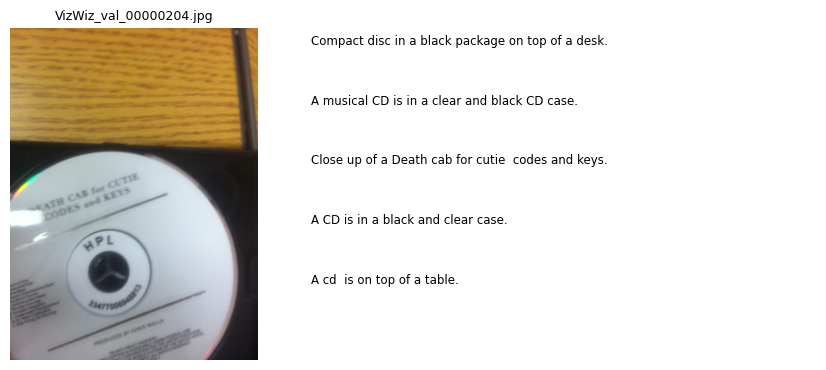

In [8]:
def show_raw_sample(df: pd.DataFrame, image_dir: Path, num_samples: int = 1) -> None:
    """Displays compact static image-caption samples for raw data inspection."""
    print(f"--- [Visualization] Sampling {num_samples} raw images ---")
    grouped = df.groupby('file_name')
    unique_files = list(grouped.groups.keys())
    samples = random.sample(unique_files, k=min(num_samples, len(unique_files)))

    for file_name in samples:
        group = grouped.get_group(file_name)
        img_path = image_dir / file_name

        fig, axes = plt.subplots(1, 2, figsize=(9, 3.8), dpi=100, gridspec_kw={'width_ratios': [1, 1.35]})

        if img_path.exists():
            try:
                with Image.open(img_path) as img:
                    axes[0].imshow(img.convert("RGB"))
            except Exception as e:
                axes[0].text(0.5, 0.5, f"Could not render image\n{e}", ha="center", va="center", wrap=True)
        else:
            axes[0].text(0.5, 0.5, "Image missing", ha="center", va="center")

        axes[0].set_title(file_name, fontsize=9)
        axes[0].axis("off")
        axes[1].axis("off")

        y = 0.98
        for _, row in group.iterrows():
            is_rejected = bool(row.get('is_rejected', 0.0))
            is_precanned = bool(row.get('is_precanned', 0.0))
            prefix = "[REJECTED] " if is_rejected else "[PRECANNED] " if is_precanned else ""
            color = plt.colormaps['viridis'](0.95) if is_rejected else plt.colormaps['viridis'](0.55) if is_precanned else 'black'
            axes[1].text(0.0, y, prefix + str(row['caption']), fontsize=8.5, color=color, va="top", wrap=True)
            y -= 0.18

        plt.tight_layout()
        plt.show()
        plt.close(fig)

# Execute Visualization
if CFG.SHOW_EDA_PLOTS:
    # Using a seed before sampling ensures we get the same random images every time we run the cell
    random.seed(CFG.SEED)
    show_raw_sample(raw_corpus_df, CFG.TRAIN_IMG_DIR, num_samples=3)


# 4. Annotation Quality Analysis

This section measures how much noise is present before cleaning. VizWiz includes captions flagged as `[REJECTED]`, `[PRECANNED]`, or both, so the analysis checks both annotation-level quality and image-level coverage after filtering.


--- [EDA] Raw Dataset Quality Analysis ---

[Annotation Breakdown]
Total Annotations : 38750
Clean/Descriptive : 33145
Precanned Only    : 4641
Rejected Only     : 438
BOTH (P & R)      : 526


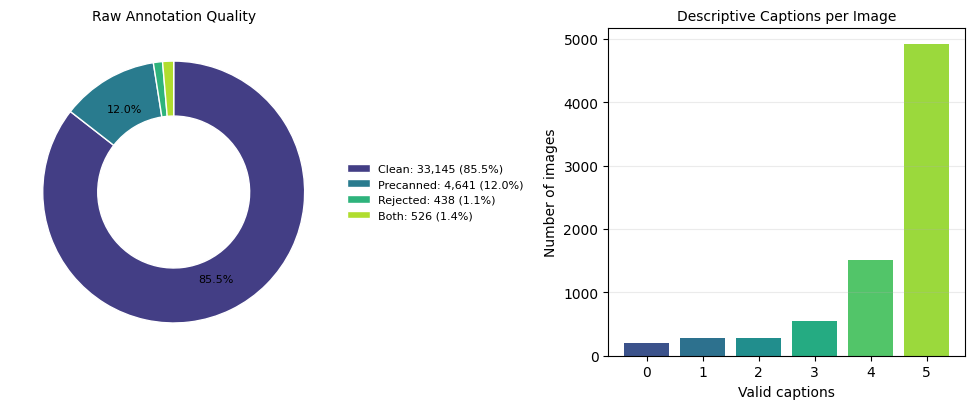

In [9]:
print("--- [EDA] Raw Dataset Quality Analysis ---")

# 1. Identify Quality Flags
# Safely handle JSON boolean/float parsing variations
is_p = (raw_corpus_df['is_precanned'] == True) | (raw_corpus_df['is_precanned'] == 1.0)
is_r = (raw_corpus_df['is_rejected'] == True) | (raw_corpus_df['is_rejected'] == 1.0)

# 2. Annotation-Level Intersection Analysis
both_count = (is_p & is_r).sum()
just_precanned = (is_p & ~is_r).sum()
just_rejected = (is_r & ~is_p).sum()
clean_count = (~is_p & ~is_r).sum()

print("\n[Annotation Breakdown]")
print(f"Total Annotations : {len(raw_corpus_df)}")
print(f"Clean/Descriptive : {clean_count}")
print(f"Precanned Only    : {just_precanned}")
print(f"Rejected Only     : {just_rejected}")
print(f"BOTH (P & R)      : {both_count}")

# 3. Image-Level "Good Caption" Distribution
raw_corpus_df['is_good'] = ~is_p & ~is_r
dist_counts = raw_corpus_df.groupby('file_name')['is_good'].sum().value_counts().sort_index()

if CFG.SHOW_EDA_PLOTS:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), dpi=100)
    cmap = plt.colormaps['viridis']
    labels = ['Clean', 'Precanned', 'Rejected', 'Both']
    values = [clean_count, just_precanned, just_rejected, both_count]
    colors = [cmap(x) for x in np.linspace(0.18, 0.88, len(labels))]

    def pct_label(pct: float) -> str:
        return f'{pct:.1f}%' if pct >= 4 else ''

    wedges, _, autotexts = axes[0].pie(
        values,
        labels=None,
        autopct=pct_label,
        startangle=90,
        counterclock=False,
        colors=colors,
        pctdistance=0.74,
        wedgeprops={'width': 0.42, 'edgecolor': 'white', 'linewidth': 1.0},
        textprops={'fontsize': 8, 'color': 'black'}
    )
    axes[0].set_title('Raw Annotation Quality', fontsize=10)
    axes[0].legend(
        wedges,
        [f'{label}: {value:,} ({value / len(raw_corpus_df):.1%})' for label, value in zip(labels, values)],
        loc='center left',
        bbox_to_anchor=(1.0, 0.5),
        frameon=False,
        fontsize=8
    )

    bar_colors = [cmap(x) for x in np.linspace(0.25, 0.85, len(dist_counts))]
    axes[1].bar(dist_counts.index.astype(str), dist_counts.values, color=bar_colors)
    axes[1].set_title('Descriptive Captions per Image', fontsize=10)
    axes[1].set_xlabel('Valid captions')
    axes[1].set_ylabel('Number of images')
    axes[1].grid(axis='y', alpha=0.25)

    plt.tight_layout()
    plt.show()
    plt.close(fig)

# Cleanup temporary EDA column
raw_corpus_df.drop(columns=['is_good'], inplace=True)


## 4.1 Quality Takeaways

* The raw VizWiz validation split contains **38,750 annotations** across **7,750 images**.
* **5,605 captions (14.5%)** are flagged as rejected, precanned, or both.
* The largest noise source is the **precanned quality-issue caption** group with **4,641 annotations** (**12.0%** of all captions). These are not useful target sentences for caption generation.
* Cleaning keeps **33,145 captions** and **7,542 usable images**, so only **208 images (2.7%)** become orphaned. This is a small image-level loss for a meaningful caption-quality improvement.
* Because some cleaned images have fewer than five reference captions, BLEU evaluation should group references dynamically by `file_name` rather than assuming exactly five references per image.


# 5. Cleaning and Internal Splits

This section removes rejected and precanned captions, drops images that no longer have valid captions, and creates an internal **80/10/10 train/validation/test split** from the official VizWiz validation set.

The split is performed at image level, not caption level. This prevents captions from the same image appearing in both training and evaluation sets.


In [10]:
print("--- [Data Filtering] ---")
original_anno_count = len(raw_corpus_df)

# 1. Silently drop Spam and Precanned
clean_corpus_df = raw_corpus_df[
    (raw_corpus_df['is_rejected'] != True) &
    (raw_corpus_df['is_rejected'] != 1.0) &
    (raw_corpus_df['is_precanned'] != True) &
    (raw_corpus_df['is_precanned'] != 1.0)
].reset_index(drop=True)

spam_removed = original_anno_count - len(clean_corpus_df)
print(f"Dropped {spam_removed} noisy annotations.")

# 2. Identify and drop orphaned images (images with 0 valid captions)
# By grouping by file_name, we ensure we only keep images that still exist in clean_corpus_df
valid_images = clean_corpus_df['file_name'].unique()
print(f"Final valid corpus size: {len(clean_corpus_df)} captions across {len(valid_images)} images.\n")

print("--- [Splitting] ---")
# 3. Perform leakage-free internal splits from the official VizWiz validation set.
# The assignment restricts source data to VizWiz val, but still asks for train/validation/test splits.
# We split by image file name so captions for the same image never leak across splits.
holdout_size = CFG.VAL_SPLIT_SIZE + CFG.TEST_SPLIT_SIZE
train_imgs, holdout_imgs = train_test_split(
    valid_images,
    test_size=holdout_size,
    random_state=CFG.SEED
)

relative_test_size = CFG.TEST_SPLIT_SIZE / holdout_size
val_imgs, test_imgs = train_test_split(
    holdout_imgs,
    test_size=relative_test_size,
    random_state=CFG.SEED
)

train_df = clean_corpus_df[clean_corpus_df['file_name'].isin(train_imgs)].reset_index(drop=True)
val_df = clean_corpus_df[clean_corpus_df['file_name'].isin(val_imgs)].reset_index(drop=True)
test_df = clean_corpus_df[clean_corpus_df['file_name'].isin(test_imgs)].reset_index(drop=True)

# Compress datatypes to save memory
train_df = reduce_mem_usage(train_df)
val_df = reduce_mem_usage(val_df)
test_df = reduce_mem_usage(test_df)

print(f"Train Split : {len(train_imgs)} images | {len(train_df)} total captions")
print(f"Val Split   : {len(val_imgs)} images | {len(val_df)} total captions")
print(f"Test Split  : {len(test_imgs)} images | {len(test_df)} total captions\n")

# 4. Handle Debug Truncation
if CFG.DEBUG:
    print("[Data Prep] DEBUG MODE: Truncating DataFrames for rapid iteration.")
    train_df = train_df.head(100)
    val_df = val_df.head(100)
    test_df = test_df.head(100)


--- [Data Filtering] ---
Dropped 5605 noisy annotations.
Final valid corpus size: 33145 captions across 7542 images.

--- [Splitting] ---
Train Split : 6033 images | 26474 total captions
Val Split   : 754 images | 3310 total captions
Test Split  : 755 images | 3361 total captions



## 5.1 Integrity Checks

Before modelling, the notebook verifies that cleaned splits are structurally sound and that referenced image files are present and readable. These checks catch common dataset issues before a long Kaggle training run reaches the PyTorch DataLoader.


In [11]:
def audit_dataset(df: pd.DataFrame, split_name: str) -> None:
    """Print structural quality checks for an image-caption split."""
    print(f"--- Data Quality Audit: {split_name} ---")

    missing_values = int(df.isnull().sum().sum())
    duplicate_ids = int(df['annotation_id'].duplicated().sum()) if 'annotation_id' in df.columns else 0
    empty_captions = int((df['caption'].astype(str).str.strip() == '').sum())
    captions_per_image = df.groupby('file_name').size()

    print(f"Missing values       : {missing_values}")
    print(f"Duplicate annotations: {duplicate_ids}")
    print(f"Empty captions       : {empty_captions}")
    print(f"Unique images        : {df['file_name'].nunique()}")
    print(f"Total captions       : {len(df)}")
    print("\nCaptions per image:")
    print(captions_per_image.value_counts().sort_index().to_string())

    if missing_values == 0 and duplicate_ids == 0 and empty_captions == 0:
        print("\nStatus: passed structural checks.")
    else:
        print("\nStatus: review anomalies before training.")


def audit_image_files(df: pd.DataFrame, image_dir: Path, split_name: str) -> Tuple[List[str], List[str]]:
    """Return missing and corrupted image file names for a split."""
    print(f"--- Image Integrity Audit: {split_name} ---")
    print(f"Image directory: {image_dir}")

    missing_files: List[str] = []
    corrupted_files: List[str] = []

    for file_name in tqdm(df['file_name'].unique(), desc=f"Verifying {split_name} images"):
        img_path = image_dir / file_name
        if not img_path.exists():
            missing_files.append(file_name)
            continue

        try:
            with Image.open(img_path) as img:
                img.verify()
        except (OSError, SyntaxError, UnidentifiedImageError):
            corrupted_files.append(file_name)

    print(f"Checked files   : {df['file_name'].nunique()}")
    print(f"Missing files   : {len(missing_files)}")
    print(f"Corrupted files : {len(corrupted_files)}")

    return missing_files, corrupted_files


def drop_bad_image_rows(df: pd.DataFrame, bad_files: Iterable[str]) -> pd.DataFrame:
    bad_files = set(bad_files)
    if not bad_files:
        return df
    before = len(df)
    cleaned = df[~df['file_name'].isin(bad_files)].reset_index(drop=True)
    print(f"Removed {before - len(cleaned)} annotations linked to missing/corrupted images.")
    return cleaned


audit_dataset(train_df, "Train")
audit_dataset(val_df, "Validation")

missing_train, corrupt_train = audit_image_files(train_df, CFG.TRAIN_IMG_DIR, "Train")
missing_val, corrupt_val = audit_image_files(val_df, CFG.VAL_IMG_DIR, "Validation")

train_df = drop_bad_image_rows(train_df, missing_train + corrupt_train)
val_df = drop_bad_image_rows(val_df, missing_val + corrupt_val)


--- Data Quality Audit: Train ---
Missing values       : 0
Duplicate annotations: 0
Empty captions       : 0
Unique images        : 6033
Total captions       : 26474

Captions per image:
1     222
2     243
3     426
4    1222
5    3920

Status: passed structural checks.
--- Data Quality Audit: Validation ---
Missing values       : 0
Duplicate annotations: 0
Empty captions       : 0
Unique images        : 754
Total captions       : 3310

Captions per image:
1     32
2     24
3     54
4    152
5    492

Status: passed structural checks.
--- Image Integrity Audit: Train ---
Image directory: /kaggle/input/datasets/tuannm3823/vizwiz/val/val


Verifying Train images: 100%|██████████| 6033/6033 [00:43<00:00, 137.40it/s]


Checked files   : 6033
Missing files   : 0
Corrupted files : 0
--- Image Integrity Audit: Validation ---
Image directory: /kaggle/input/datasets/tuannm3823/vizwiz/val/val


Verifying Validation images: 100%|██████████| 754/754 [00:05<00:00, 139.06it/s]

Checked files   : 754
Missing files   : 0
Corrupted files : 0


## 5.2 Cleaning Impact and Split Balance

The first EDA pass measures how much noisy text is removed. This deeper check asks whether cleaning changes the training signal in a harmful way: how many images become unusable, how many references remain per image, and whether the train/validation/test splits have comparable caption coverage.

The results support the current plan. Cleaning retains **85.5% of annotations** and **97.3% of images** while removing low-value target text. The internal splits remain well balanced, with roughly **4.4 references per image** and a median of **5 references** per image.


--- Cleaning Impact Summary ---


,metric,value
0,Raw annotations,38750
1,Clean annotations,33145
2,Removed annotations,5605
3,Raw images,7750
4,Usable clean images,7542
5,Orphaned images after cleaning,208
6,Annotation retention rate,85.5%
7,Image retention rate,97.3%


--- Reference Coverage by Split ---


,split,images,captions,mean_refs_per_image,median_refs_per_image,images_with_1_ref_pct,images_with_5_refs_pct
0,Train,6033,26474,4.39,5.0,3.68,64.98
1,Validation,754,3310,4.39,5.0,4.24,65.25
2,Test,755,3361,4.45,5.0,2.65,67.02


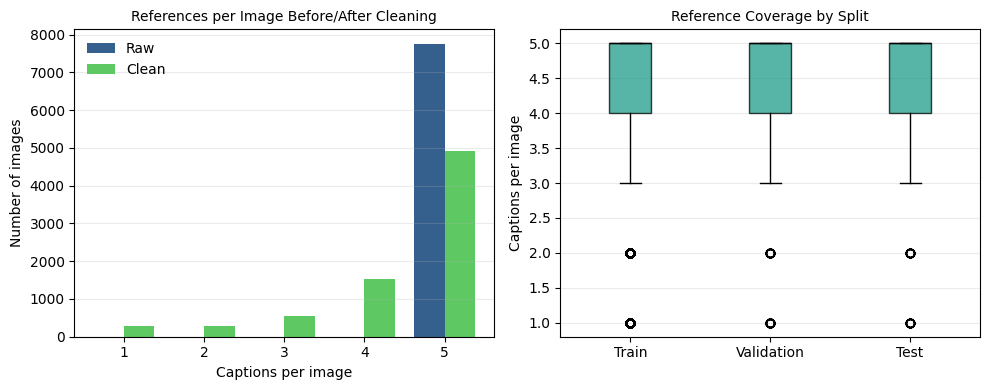

In [12]:
def summarize_cleaning_impact(raw_df: pd.DataFrame, clean_df: pd.DataFrame) -> pd.DataFrame:
    raw_images = raw_df['file_name'].nunique()
    clean_images = clean_df['file_name'].nunique()
    removed_annotations = len(raw_df) - len(clean_df)
    orphaned_images = raw_images - clean_images

    summary = pd.DataFrame({
        'metric': [
            'Raw annotations',
            'Clean annotations',
            'Removed annotations',
            'Raw images',
            'Usable clean images',
            'Orphaned images after cleaning',
            'Annotation retention rate',
            'Image retention rate',
        ],
        'value': [
            len(raw_df),
            len(clean_df),
            removed_annotations,
            raw_images,
            clean_images,
            orphaned_images,
            f'{len(clean_df) / len(raw_df):.1%}',
            f'{clean_images / raw_images:.1%}',
        ]
    })
    return summary


def summarize_reference_coverage(*splits: Tuple[str, pd.DataFrame]) -> pd.DataFrame:
    rows = []
    for split_name, df in splits:
        refs = df.groupby('file_name').size()
        rows.append({
            'split': split_name,
            'images': int(refs.size),
            'captions': int(len(df)),
            'mean_refs_per_image': refs.mean(),
            'median_refs_per_image': refs.median(),
            'images_with_1_ref_pct': (refs.eq(1).mean() * 100),
            'images_with_5_refs_pct': (refs.eq(5).mean() * 100),
        })
    return pd.DataFrame(rows)


cleaning_summary = summarize_cleaning_impact(raw_corpus_df, clean_corpus_df)
coverage_summary = summarize_reference_coverage(('Train', train_df), ('Validation', val_df), ('Test', test_df))

print('--- Cleaning Impact Summary ---')
display(cleaning_summary)

print('--- Reference Coverage by Split ---')
display(coverage_summary.round(2))

if CFG.SHOW_EDA_PLOTS:
    cmap = plt.colormaps['viridis']
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=100)

    raw_refs = raw_corpus_df.groupby('file_name').size().value_counts().sort_index()
    clean_refs = clean_corpus_df.groupby('file_name').size().value_counts().sort_index()
    ref_index = sorted(set(raw_refs.index).union(set(clean_refs.index)))
    x = np.arange(len(ref_index))
    width = 0.38

    axes[0].bar(x - width / 2, [raw_refs.get(i, 0) for i in ref_index], width, label='Raw', color=cmap(0.30))
    axes[0].bar(x + width / 2, [clean_refs.get(i, 0) for i in ref_index], width, label='Clean', color=cmap(0.75))
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(ref_index)
    axes[0].set_title('References per Image Before/After Cleaning', fontsize=10)
    axes[0].set_xlabel('Captions per image')
    axes[0].set_ylabel('Number of images')
    axes[0].legend(frameon=False)
    axes[0].grid(axis='y', alpha=0.25)

    split_ref_counts = [train_df.groupby('file_name').size(), val_df.groupby('file_name').size(), test_df.groupby('file_name').size()]
    axes[1].boxplot(split_ref_counts, labels=['Train', 'Validation', 'Test'], patch_artist=True,
                    boxprops={'facecolor': cmap(0.55), 'alpha': 0.75}, medianprops={'color': 'black'})
    axes[1].set_title('Reference Coverage by Split', fontsize=10)
    axes[1].set_ylabel('Captions per image')
    axes[1].grid(axis='y', alpha=0.25)

    plt.tight_layout()
    plt.show()
    plt.close(fig)


## 5.3 Split Takeaways

* **No split-strategy change is needed.** The internal train/validation/test sets remain representative after cleaning.
* **BLEU should still be interpreted with reference coverage in mind.** A small minority of images have only one valid caption, so those examples provide less flexible reference matching than fully annotated images.
* **The filtering policy is justified.** Removing noisy labels sacrifices only **2.7%** of images while improving target-caption quality for both the baseline and attention models.


# 6. Vocabulary and Sequence Analysis

Captioning models operate on token IDs rather than raw text. This section builds the vocabulary, reserves special tokens, and checks whether the selected frequency threshold and maximum sequence length preserve enough language signal for training.

The vocabulary includes `<PAD>`, `<START>`, `<END>`, and `<UNK>` tokens. Rare words are mapped to `<UNK>` using `VOCAB_MIN_FREQ`, which reduces vocabulary size while keeping common caption language available to the model.


In [13]:
class Vocabulary:
    """
    Handles the bidirectional mapping between string tokens and integer IDs.
    """
    def __init__(self, freq_threshold: int = CFG.VOCAB_MIN_FREQ) -> None:
        self.freq_threshold = freq_threshold

        # Initialize dictionaries with reserved MLOps special tokens
        self.itos: Dict[int, str] = {0: "<PAD>", 1: "<START>", 2: "<END>", 3: "<UNK>"}
        self.stoi: Dict[str, int] = {"<PAD>": 0, "<START>": 1, "<END>": 2, "<UNK>": 3}
        self.idx: int = 4

    def __len__(self) -> int:
        """Returns the total number of unique words in the vocabulary."""
        return len(self.itos)

    def tokenize(self, text: str) -> List[str]:
        """Converts raw text to lowercase and isolates punctuation."""
        text = str(text).lower()
        # Ensure punctuation is treated as separate tokens to improve context learning
        for punc in [".", ",", "!", "?", "\"", "'", "(", ")"]:
            text = text.replace(punc, f" {punc} ")
        return text.split()

    def build_vocabulary(self, sentence_list: List[str]) -> None:
        """Populates the stoi and itos dictionaries based on token frequencies."""
        print(f"--- [Vocabulary] Building index with threshold >= {self.freq_threshold} ---")
        frequencies = Counter()

        for sentence in sentence_list:
            for word in self.tokenize(sentence):
                frequencies[word] += 1

        # Only add words that meet the frequency requirement to prevent overfitting on typos
        for word, count in frequencies.items():
            if count >= self.freq_threshold:
                self.stoi[word] = self.idx
                self.itos[self.idx] = word
                self.idx += 1

        print(f"[Vocabulary] Processed {len(sentence_list)} sentences. Indexed {len(self.itos)} unique tokens.")

    def numericalize(self, text: str) -> List[int]:
        """Converts a raw string into a list of integer tensor indices."""
        tokenized_text = self.tokenize(text)
        return [
            self.stoi.get(token, self.stoi["<UNK>"])
            for token in tokenized_text
        ]

In [14]:
# 1. Extract all clean training captions
# We ONLY build the vocabulary on the training set to prevent data leakage from the val set
train_captions = train_df['caption'].tolist()

# 2. Instantiate and build the Vocabulary object
vocab = Vocabulary(freq_threshold=CFG.VOCAB_MIN_FREQ)
vocab.build_vocabulary(train_captions)

# 3. Validation Check
if CFG.DEBUG or CFG.MODE == "train":
    # Test the numericalization pipeline on the first available caption
    sample_text = train_captions[0]
    print(f"\n[Validation] Source Text : {sample_text}")
    print(f"[Validation] Tokenized   : {vocab.tokenize(sample_text)}")
    print(f"[Validation] Encoded IDs : {vocab.numericalize(sample_text)}")

--- [Vocabulary] Building index with threshold >= 2 ---
[Vocabulary] Processed 26474 sentences. Indexed 6439 unique tokens.


--- [EDA] NLP Token Distribution Analysis ---


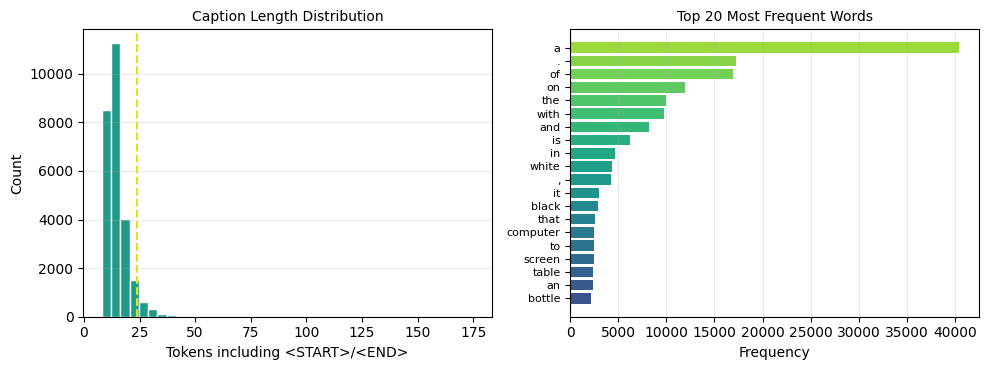


[NLP Summary]
Shortest Caption : 8 tokens
Longest Caption  : 175 tokens
Average Caption  : 15 tokens
95% Threshold    : 24 tokens
Actionable Insight: Set CFG.MAX_SEQ_LEN to ~24 to capture most data without wasting VRAM.


In [15]:
def analyze_nlp_distributions(captions: List[str], vocab: Vocabulary) -> None:
    """
    Analyzes caption lengths and frequent words to inform sequence length and vocabulary choices.
    """
    print("--- [EDA] NLP Token Distribution Analysis ---")

    seq_lengths = [len(vocab.tokenize(cap)) + 2 for cap in captions]

    all_words = []
    for cap in captions:
        all_words.extend(vocab.tokenize(cap))
    word_counts = pd.Series(all_words).value_counts()

    percentile_95 = np.percentile(seq_lengths, 95)

    if CFG.SHOW_EDA_PLOTS:
        fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), dpi=100)
        cmap = plt.colormaps['viridis']

        axes[0].hist(seq_lengths, bins=40, color=cmap(0.55), edgecolor='white')
        axes[0].axvline(percentile_95, color=cmap(0.95), linestyle='--', linewidth=1.5)
        axes[0].set_title('Caption Length Distribution', fontsize=10)
        axes[0].set_xlabel('Tokens including <START>/<END>')
        axes[0].set_ylabel('Count')
        axes[0].grid(axis='y', alpha=0.25)

        top_20 = word_counts.head(20).sort_values()
        axes[1].barh(top_20.index, top_20.values, color=cmap(np.linspace(0.25, 0.85, len(top_20))))
        axes[1].set_title('Top 20 Most Frequent Words', fontsize=10)
        axes[1].set_xlabel('Frequency')
        axes[1].tick_params(axis='y', labelsize=8)
        axes[1].grid(axis='x', alpha=0.25)

        plt.tight_layout()
        plt.show()
        plt.close(fig)

    print(f"\n[NLP Summary]")
    print(f"Shortest Caption : {min(seq_lengths)} tokens")
    print(f"Longest Caption  : {max(seq_lengths)} tokens")
    print(f"Average Caption  : {int(np.mean(seq_lengths))} tokens")
    print(f"95% Threshold    : {int(percentile_95)} tokens")
    print(f"Actionable Insight: Set CFG.MAX_SEQ_LEN to ~{int(percentile_95)} to capture most data without wasting VRAM.")

# Execute the EDA on the clean training captions
if CFG.SHOW_EDA_PLOTS:
    analyze_nlp_distributions(train_captions, vocab)


## 6.1 Vocabulary Coverage and Truncation Risk

A captioning model can only learn from tokens that survive the vocabulary threshold and sequence-length cap. This diagnostic quantifies how much validation text becomes `<UNK>` and how many captions would be truncated by `MAX_SEQ_LEN`.

The output is shown vertically because this diagnostic is a single-row health check. The most important signal is that the current settings are not overly aggressive: the indexed vocabulary covers **98.87%** of training tokens, validation OOV is only **2.93%**, and fewer than **4%** of captions exceed `MAX_SEQ_LEN`.


--- Vocabulary Coverage and Truncation Risk ---


,metric,value
0,indexed_vocab_size,6435.00
1,unique_train_tokens,10342.00
2,excluded_rare_tokens,3907.00
3,train_token_coverage_pct,98.87
4,validation_oov_token_pct,2.96
5,test_oov_token_pct,2.91
6,train_truncated_caption_pct,3.67
7,validation_truncated_caption_pct,3.05
8,test_truncated_caption_pct,3.12
9,train_p95_length,24.00


Training decision: keep VOCAB_MIN_FREQ=2 and MAX_SEQ_LEN=25. OOV and truncation rates are low enough for the current baseline and attention experiments.


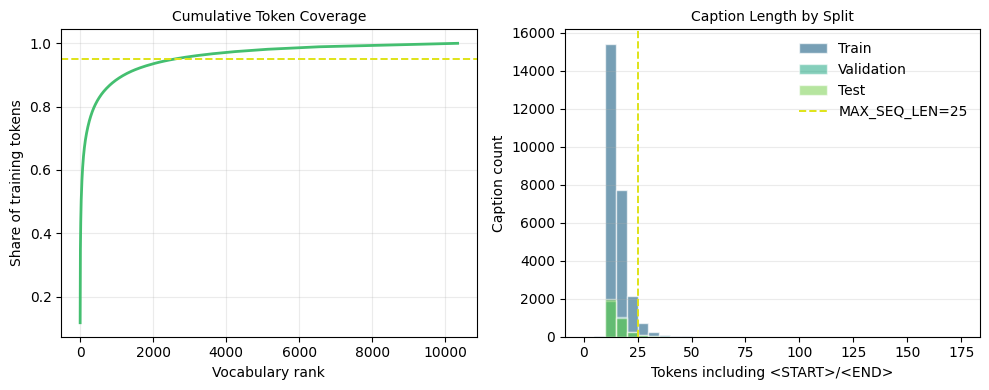

In [16]:
def analyze_vocabulary_coverage(train_captions: List[str], val_captions: List[str], test_captions: List[str], vocab: Vocabulary) -> pd.DataFrame:
    train_tokens = [token for caption in train_captions for token in vocab.tokenize(caption)]
    val_tokens = [token for caption in val_captions for token in vocab.tokenize(caption)]
    test_tokens = [token for caption in test_captions for token in vocab.tokenize(caption)]
    train_counts = Counter(train_tokens)
    indexed_words = set(vocab.stoi) - {'<PAD>', '<START>', '<END>', '<UNK>'}

    val_oov_tokens = [token for token in val_tokens if token not in indexed_words]
    test_oov_tokens = [token for token in test_tokens if token not in indexed_words]
    train_lengths = np.array([len(vocab.tokenize(caption)) + 2 for caption in train_captions])
    val_lengths = np.array([len(vocab.tokenize(caption)) + 2 for caption in val_captions])
    test_lengths = np.array([len(vocab.tokenize(caption)) + 2 for caption in test_captions])

    rows = [{
        'indexed_vocab_size': len(indexed_words),
        'unique_train_tokens': len(train_counts),
        'excluded_rare_tokens': len(set(train_counts) - indexed_words),
        'train_token_coverage_pct': 100 * sum(count for token, count in train_counts.items() if token in indexed_words) / max(1, len(train_tokens)),
        'validation_oov_token_pct': 100 * len(val_oov_tokens) / max(1, len(val_tokens)),
        'test_oov_token_pct': 100 * len(test_oov_tokens) / max(1, len(test_tokens)),
        'train_truncated_caption_pct': 100 * np.mean(train_lengths > CFG.MAX_SEQ_LEN),
        'validation_truncated_caption_pct': 100 * np.mean(val_lengths > CFG.MAX_SEQ_LEN),
        'test_truncated_caption_pct': 100 * np.mean(test_lengths > CFG.MAX_SEQ_LEN),
        'train_p95_length': np.percentile(train_lengths, 95),
        'validation_p95_length': np.percentile(val_lengths, 95),
        'test_p95_length': np.percentile(test_lengths, 95),
    }]
    return pd.DataFrame(rows)


coverage = analyze_vocabulary_coverage(train_df['caption'].tolist(), val_df['caption'].tolist(), test_df['caption'].tolist(), vocab).round(2)
coverage_vertical = coverage.T.reset_index()
coverage_vertical.columns = ['metric', 'value']

print('--- Vocabulary Coverage and Truncation Risk ---')
display(coverage_vertical)

print('Training decision: keep VOCAB_MIN_FREQ=2 and MAX_SEQ_LEN=25. OOV and truncation rates are low enough for the current baseline and attention experiments.')

if CFG.SHOW_EDA_PLOTS:
    cmap = plt.colormaps['viridis']
    token_counts = Counter(token for caption in train_captions for token in vocab.tokenize(caption))
    freqs = np.array(sorted(token_counts.values(), reverse=True))
    cumulative = np.cumsum(freqs) / freqs.sum()

    fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=100)
    axes[0].plot(np.arange(1, len(cumulative) + 1), cumulative, color=cmap(0.70), linewidth=2)
    axes[0].axhline(0.95, color=cmap(0.95), linestyle='--', linewidth=1.4)
    axes[0].set_title('Cumulative Token Coverage', fontsize=10)
    axes[0].set_xlabel('Vocabulary rank')
    axes[0].set_ylabel('Share of training tokens')
    axes[0].grid(alpha=0.25)

    train_lengths = [len(vocab.tokenize(caption)) + 2 for caption in train_df['caption']]
    val_lengths = [len(vocab.tokenize(caption)) + 2 for caption in val_df['caption']]
    test_lengths = [len(vocab.tokenize(caption)) + 2 for caption in test_df['caption']]
    bins = np.arange(0, max(max(train_lengths), max(val_lengths)) + 5, 5)
    axes[1].hist(train_lengths, bins=bins, alpha=0.65, label='Train', color=cmap(0.35), edgecolor='white')
    axes[1].hist(val_lengths, bins=bins, alpha=0.55, label='Validation', color=cmap(0.60), edgecolor='white')
    axes[1].hist(test_lengths, bins=bins, alpha=0.55, label='Test', color=cmap(0.80), edgecolor='white')
    axes[1].axvline(CFG.MAX_SEQ_LEN, color=cmap(0.95), linestyle='--', linewidth=1.4, label=f'MAX_SEQ_LEN={CFG.MAX_SEQ_LEN}')
    axes[1].set_title('Caption Length by Split', fontsize=10)
    axes[1].set_xlabel('Tokens including <START>/<END>')
    axes[1].set_ylabel('Caption count')
    axes[1].legend(frameon=False)
    axes[1].grid(axis='y', alpha=0.25)

    plt.tight_layout()
    plt.show()
    plt.close(fig)


## 6.2 Vocabulary Takeaways

* **Keep `VOCAB_MIN_FREQ = 2`.** The threshold indexes **6,435 words** and still covers **98.87%** of training-token occurrences. The excluded **3,907 rare tokens** are mostly long-tail wording, spelling variation, or very low-frequency noise.
* **Keep `MAX_SEQ_LEN = 25`.** The 95th percentile is **24 tokens** for training and **23 tokens** for validation. Only **3.67%** of training captions and **3.09%** of validation captions are truncated.
* **No architecture change is needed from vocabulary coverage alone.** Validation OOV is **2.93%**, so weak generated captions later are more likely to come from visual grounding, limited model capacity, or decoding behaviour than from severe vocabulary loss.


## 6.3 Modelling Implications

The EDA supports the current training plan: use cleaned captions, keep the image-level 80/10/10 internal split, train with `VOCAB_MIN_FREQ = 2`, and cap sequences at `MAX_SEQ_LEN = 25`.

The frequent-token distribution also shows a strong VizWiz domain bias toward everyday indoor objects, screens, tables, packaging, bottles, and high-frequency colour terms. During visual inspection, the models should therefore be expected to perform better on common household scenes than on rare objects, unusual viewpoints, or heavily degraded images.

Because the dataset contains noisy framing and partial objects, the attention model remains a sensible refinement after the baseline. It gives the decoder access to spatial image features rather than forcing the entire image into one global vector.
